### Multiple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#### Predict forest fire

In [3]:
forests = pd.read_csv('forests.csv')

In [7]:
forests.head()

,temp,humid,wind,rain,FFMC,DMC,DC,ISI,BUI,FWI,region,fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,Bejaia,False
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,Bejaia,False
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,Bejaia,False
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,Bejaia,False
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,Bejaia,False


In [9]:
# check multicollinearity with a heatmap
corr_grid = forests.corr(numeric_only=True)

<Axes: >

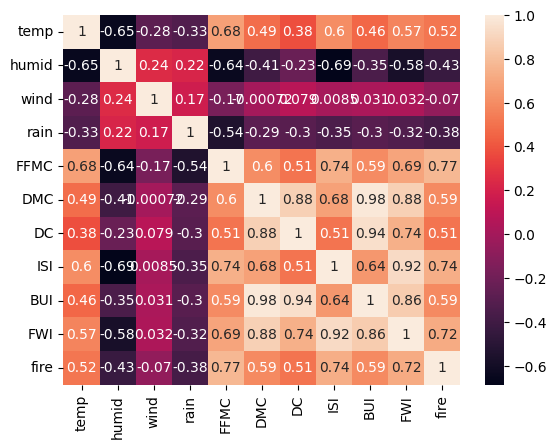

In [10]:
sns.heatmap(corr_grid, xticklabels=corr_grid.columns, yticklabels=corr_grid.columns, annot=True)

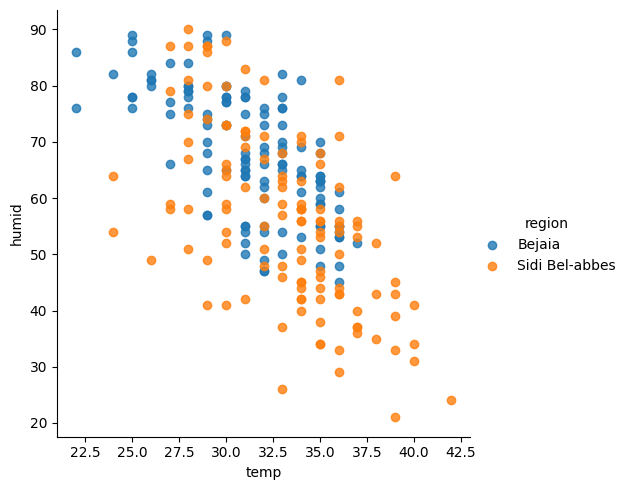

In [5]:
# plot humidity vs temperature
sns.lmplot(x='temp',y='humid',hue='region',data=forests, fit_reg = False)

In [6]:
# model predicting humidity
modelH = sm.OLS.from_formula('humid ~ temp + region',data=forests).fit()
modelH.params

Intercept                   142.575801
region[T.Sidi Bel-abbes]     -7.247538
temp                         -2.392547
dtype: float64

In [ ]:
#equations
## Full equation:
# humid = 142.6 - 2.4*temp - 7.2*region
## For Bejaia:
# humid = 142.6 - 2.4*temp
## For Sidi Bel-abbes:
# humid = 135.3 - 2.4*temp

In [ ]:
#interpretations
## Coefficient on temp:
# Holding region constant, the coefficient on temperature indicates that for every temperature increase of one-degree Celsius, relative humidity decreases by 2.4%. 
## For Bejaia equation:
# The intercept indicates that a temperature of zero degrees Celsius is associated with an average relative humidity of 142.6%. (This interpretation is doesn't make sense as relative humidity can't go past 100% and 0 degrees C is far below the temperatures available in our dataset, but we learn the regression line starts higher for Bejaia.)
## For Sidi Bel-abbes equation:
# The intercept indicates that a temperature of zero degrees Celsius is associated with an average relative humidity of 135.3%. (This interpretation is doesn't make sense as relative humidity can't go past 100% and 0 degrees C is far below the temperatures available in our dataset, but we learn the regression line starts lower for Sidi Bel-abbes.)

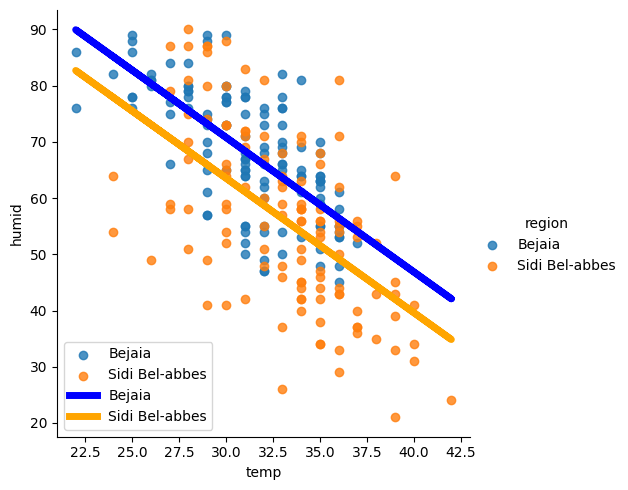

In [16]:
# plot regression lines
sns.lmplot(x='temp',y='humid',hue='region',data=forests, fit_reg = False)
plt.plot(forests.temp, modelH.params.iloc[0]+modelH.params.iloc[1]*0+modelH.params.iloc[2]*forests.temp, color='blue',linewidth=5, label='Bejaia')
plt.plot(forests.temp, modelH.params.iloc[0]+modelH.params.iloc[1]*1+modelH.params.iloc[2]*forests.temp, color='orange',linewidth=5, label='Sidi Bel-abbes')
plt.legend()

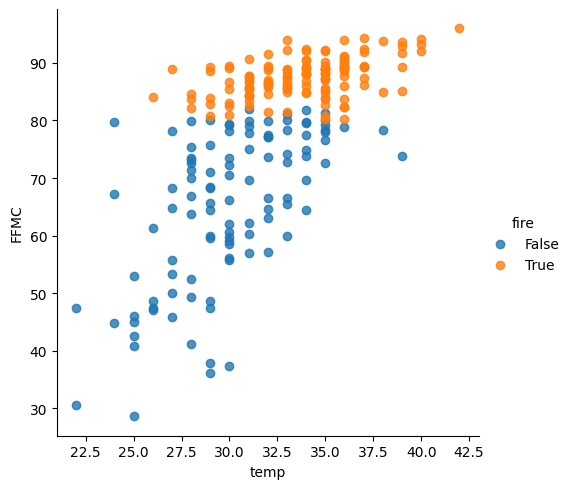

In [24]:
# plot FFMC vs temperature
sns.lmplot(x='temp',y='FFMC',hue='fire',data=forests, fit_reg = False)

In [18]:
# model predicting FFMC with interaction
modelF = sm.OLS.from_formula('FFMC ~ temp + fire + temp:fire',data=forests).fit()
modelF.params

Intercept            -8.108891
fire[T.True]         76.788000
temp                  2.445159
temp:fire[T.True]    -1.887219
dtype: float64

In [ ]:
#equations
## Full equation:
# FFMC = -8.1 + 2.4*temp + 76.8*fire - 1.9*temp*fire
## For locations without fire:
# FFMC = -8.1 + 2.4*temp
## For locations with fire:
# FFMC = 68.7 + 0.5*temp

In [ ]:
#interpretations
## For locations without fire:
# FFMC = -8.1 + 2.4*temp
# For every temperature increase of one degree Celsius, FFMC score increases by 2.4 points.
## For locations with fire:
# FFMC = 68.7 + 0.5*temp
# The regression line has an intercept 76.8 points greater and a slope 1.9 points less than those of the locations that did not end up experiencing a fire. 
# For every temperature increase of one degree Celsius, FFMC score increases by 0.5 points.

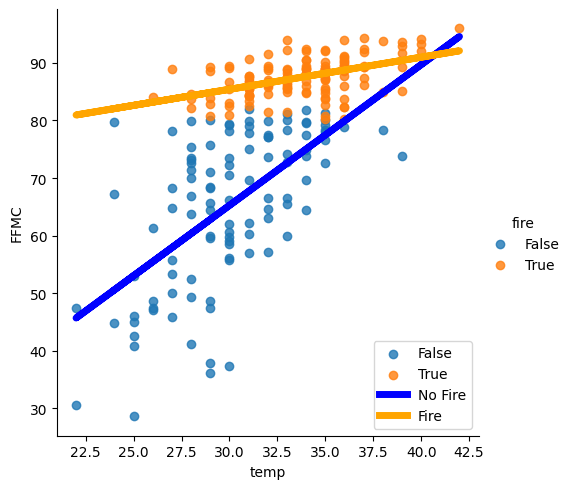

In [19]:
# plot regression lines
sns.lmplot(x='temp',y='FFMC',hue='fire',data=forests, fit_reg = False)
plt.plot(forests.temp, modelF.params.iloc[0]+modelF.params.iloc[1]*0+modelF.params.iloc[2]*forests.temp + modelF.params.iloc[3]*forests.temp*0, color='blue',linewidth=5, label='No Fire')
plt.plot(forests.temp, modelF.params.iloc[0]+modelF.params.iloc[1]*1+modelF.params.iloc[2]*forests.temp + modelF.params.iloc[3]*forests.temp*1, color='orange',linewidth=5, label='Fire')
plt.legend()

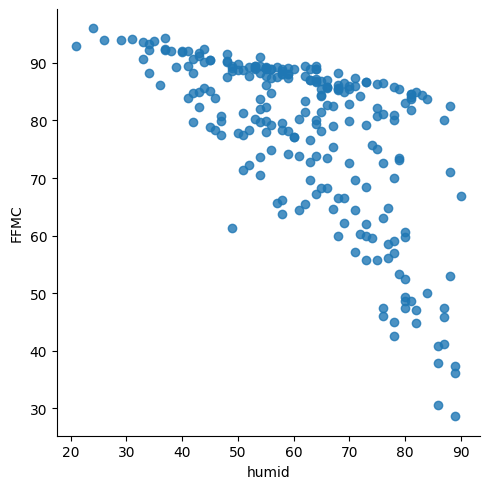

In [27]:
# plot FFMC vs humid
sns.lmplot(x='humid',y='FFMC',data=forests, fit_reg = False)

In [20]:
# polynomial model predicting FFMC
modelP = sm.OLS.from_formula('FFMC ~ humid + np.power(humid,2)',data=forests).fit()
modelP.params

Intercept             77.634041
humid                  0.752165
np.power(humid, 2)    -0.011420
dtype: float64

In [ ]:
#regression equation
# FFMC = 77.63 + 0.75*humid - 0.01*humid^2

In [21]:
# sample predicted values
print(modelP.params.iloc[0] + modelP.params.iloc[1]*25 + modelP.params.iloc[2]*np.power(25,2))
print(modelP.params.iloc[0] + modelP.params.iloc[1]*35 + modelP.params.iloc[2]*np.power(35,2))
print(modelP.params.iloc[0] + modelP.params.iloc[1]*60 + modelP.params.iloc[2]*np.power(60,2))
print(modelP.params.iloc[0] + modelP.params.iloc[1]*70 + modelP.params.iloc[2]*np.power(70,2))

89.30075097131991
89.97048469230963
81.65244328464414
74.32827643752202


In [ ]:
#interpretation of relationship
# For lower humidity levels, increases in relative humidity are associated with very small increases in FFMC score, until about 35% relative humidity. After this point increases in humidity are associated with increasingly bigger decreases in FFMC score.

In [30]:
# multiple variables to predict FFMC
modelFFMC = sm.OLS.from_formula('FFMC ~ temp + rain + wind + humid',data=forests).fit()
modelFFMC.params

Intercept    50.461574
temp          1.377774
rain         -2.614067
wind          0.419784
humid        -0.345373
dtype: float64

In [31]:
# predict FWI from ISI and BUI
modelFWI = sm.OLS.from_formula('FWI ~ ISI + BUI',data=forests).fit()
modelFWI.params

Intercept   -2.270676
ISI          1.133400
BUI          0.235526
dtype: float64